In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [32]:
data_set=pd.read_csv("../data/cleaned_data.csv")
data_set.head()

,DateTime,latitude,longitude,depth,magnitude,magnitudeType,nst,gap,dmin,rms,place,type,horizontalError,depthError,magError,magNst
0,2025-12-07T02:43:07.342Z,29.8698,80.9384,43.404,4.4,mb,21.0,166.0,8.856,0.94,"37 km E of Dārchulā, Nepal",earthquake,13.18,9.350,0.144,14.0
1,2025-12-04T11:59:01.015Z,29.1109,87.0043,10.000,4.1,mb,36.0,168.0,3.646,1.26,"130 km N of Lobuche, Nepal",earthquake,10.55,1.930,0.103,26.0
2,2025-11-10T22:44:15.027Z,29.1757,86.8367,10.000,4.2,mb,14.0,164.0,3.779,0.57,"136 km N of Lobuche, Nepal",earthquake,12.27,1.963,0.199,7.0
3,2025-11-03T20:57:22.312Z,28.5267,87.3673,10.000,4.7,mb,64.0,79.0,3.493,0.77,"84 km NE of Lobuche, Nepal",earthquake,9.64,1.872,0.058,89.0
4,2025-10-21T14:59:40.611Z,29.0245,85.3683,10.000,4.1,mb,25.0,163.0,5.072,0.44,"35 km SSE of Saga, China",earthquake,9.46,1.840,0.103,26.0


In [33]:
print("ROWS AND COLUMN")
print(data_set.shape)


ROWS AND COLUMN
(1536, 16)


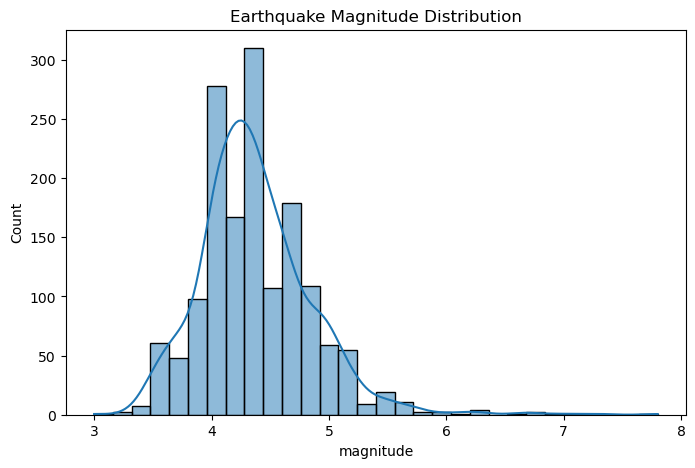

In [34]:
plt.figure(figsize=(8,5))
sns.histplot(data_set['magnitude'],bins=30,kde=True)
plt.title("Earthquake Magnitude Distribution")
plt.show()

Most earthquakes recorded in Nepal have magnitudes between 3 and 5. 
Large magnitude events above 6 are relatively rare.

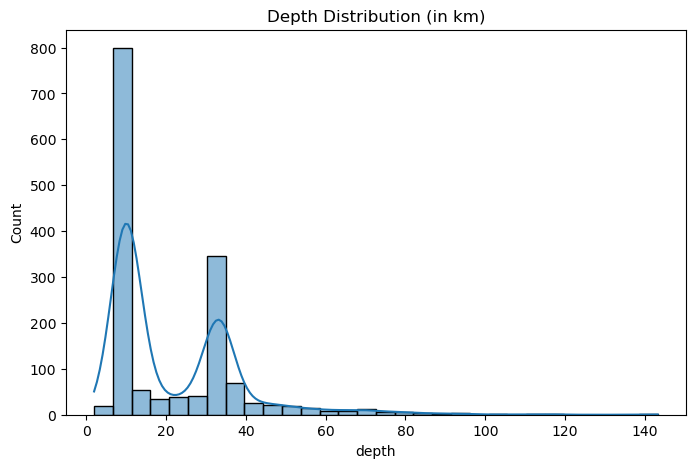

In [35]:
plt.figure(figsize=(8,5))
sns.histplot(data_set['depth'],bins=30,kde=True) #Kernel Density Estimate curve over a histogram.
plt.title("Depth Distribution (in km)")

plt.show()

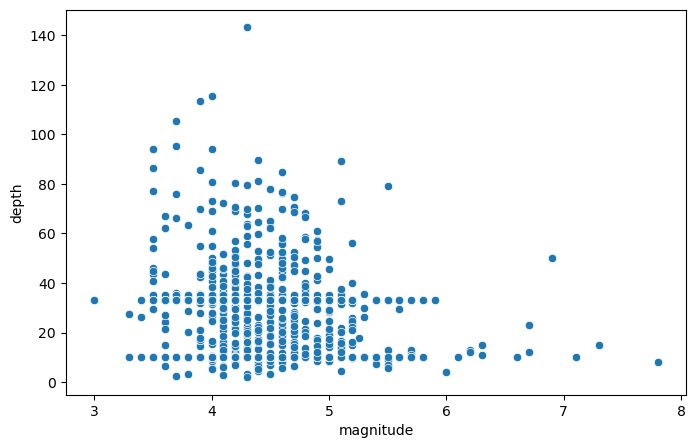

In [36]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='magnitude',
    y='depth',
    data=data_set
)

plt.show()

No strong linear relationship exists between earthquake depth and magnitude,
though some high-magnitude earthquakes occur at moderate depths.

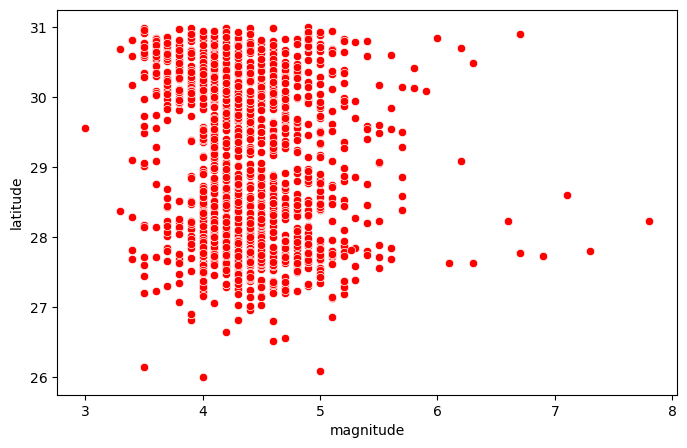

In [37]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    y='latitude',
    x='magnitude',
    color="red",
    
    data=data_set
    
)

plt.show()

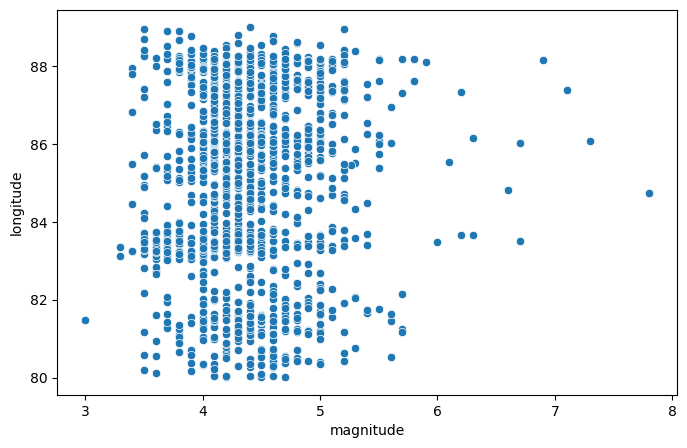

In [38]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    y='longitude',
    x='magnitude',
    data=data_set
)

plt.show()

Certain latitude-longitude regions show concentrations of stronger earthquakes, indicating spatial clustering of seismic activity.

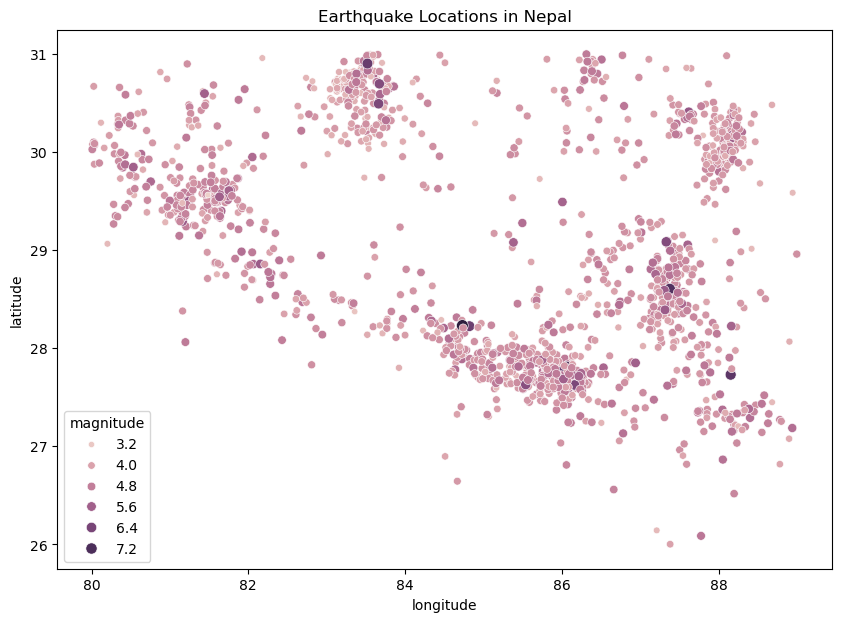

In [39]:

plt.figure(figsize=(10,7))

sns.scatterplot(
    x='longitude',
    y='latitude',
    hue='magnitude',
    size='magnitude',
    data=data_set
)

plt.title("Earthquake Locations in Nepal")

plt.show()

Earthquakes are concentrated along tectonically active regions near the Himalayan fault system

In [42]:
data_set['DateTime']=pd.to_datetime(data_set['DateTime'])
data_set['year']=data_set['DateTime'].dt.year
data_set.columns


Index(['DateTime', 'latitude', 'longitude', 'depth', 'magnitude',
       'magnitudeType', 'nst', 'gap', 'dmin', 'rms', 'place', 'type',
       'horizontalError', 'depthError', 'magError', 'magNst', 'year'],
      dtype='object')

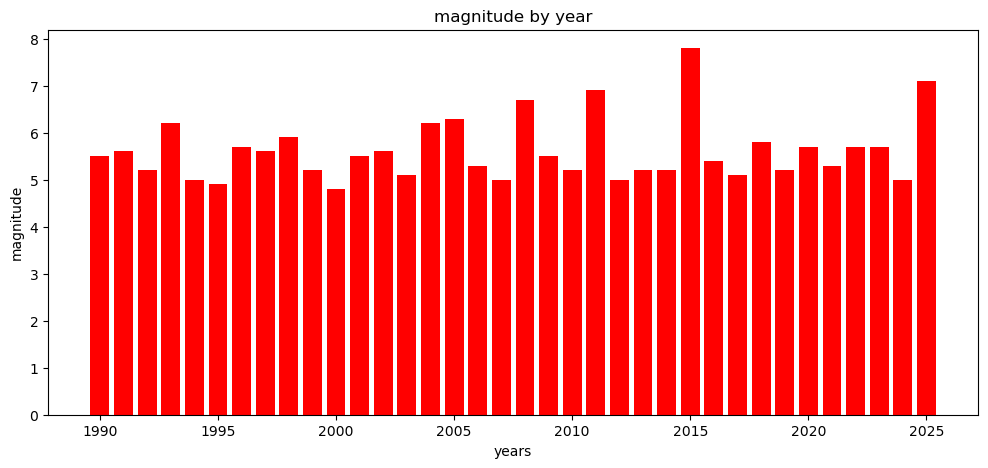

In [49]:

plt.figure(figsize=(12,5))
plt.bar(data_set['year'],data_set['magnitude'],color="red",)
plt.xlabel("years")
plt.ylabel("magnitude")
plt.title("magnitude by year")
plt.show()

Average earthquake magnitude remains relatively stable over time, although some years contain significantly stronger events.

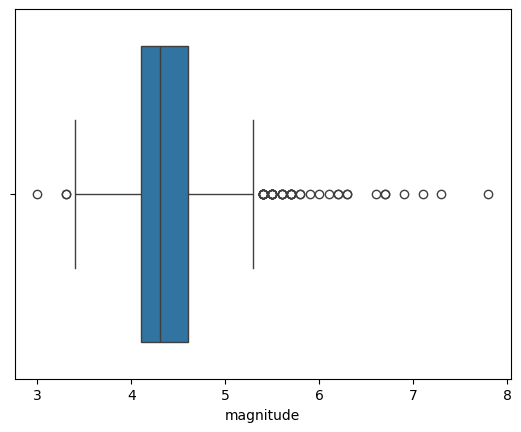

In [50]:
sns.boxplot(x=data_set['magnitude'])
plt.show()

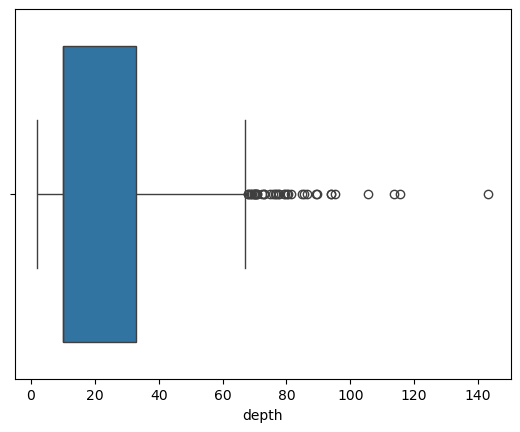

In [51]:
sns.boxplot(x=data_set['depth'])

plt.show()

In [52]:
numeric_df = data_set.select_dtypes(include=np.number)

corr = numeric_df.corr()

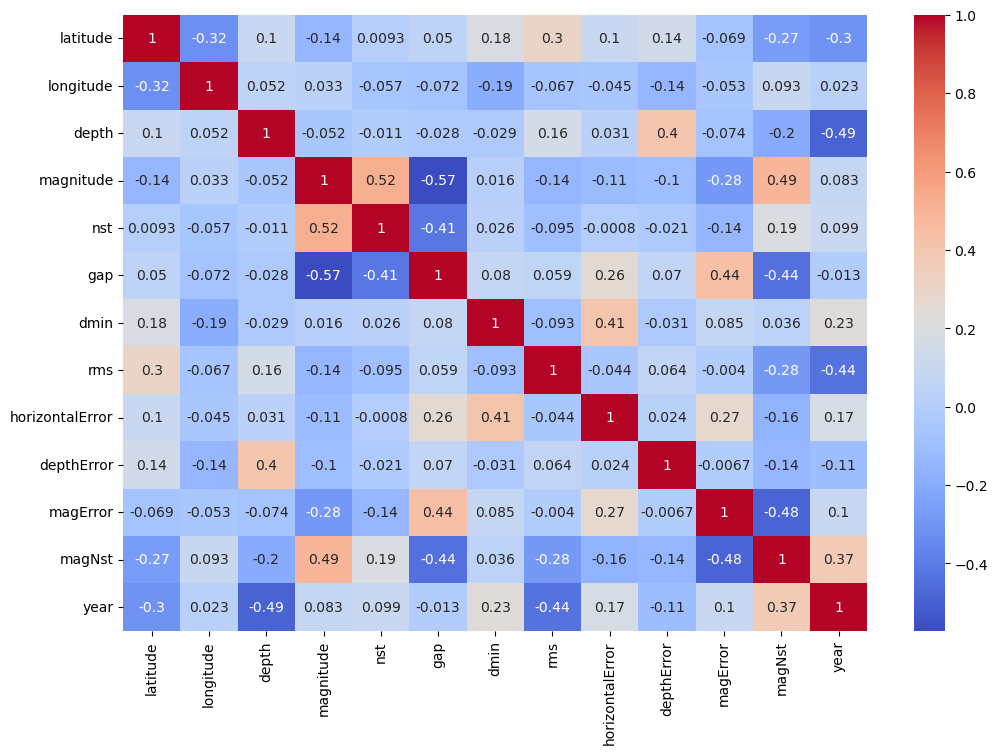

In [53]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.show()

In [55]:
corr['magnitude'].sort_values(
    ascending=False
)

magnitude          1.000000
nst                0.519215
magNst             0.485623
year               0.083343
longitude          0.032688
dmin               0.016289
depth             -0.051914
depthError        -0.101365
horizontalError   -0.114137
latitude          -0.137263
rms               -0.140742
magError          -0.284354
gap               -0.571929
Name: magnitude, dtype: float64

Depth, latitude, longitude, and seismic quality indicators exhibit the strongest relationships with earthquake magnitude.